In [ ]:
### PY-NOTEBOOK CELL-1 : Libraries and Packages ###

!pip install neuralforecast

# GENERAL
import pandas as pd
import numpy as np
import os
import joblib
import pickle
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# STATISTICAL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.var_model import VAR

# MACHINE LEARNING
!pip install catboost
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, early_stopping

# DEEP LEARNING
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# TRANSFORMERS

from neuralforecast import NeuralForecast
from neuralforecast.models import Informer, PatchTST, TFT

# MODEL EVALUATION
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.6 MB/s eta 0:00:00


In [ ]:
### PY-NOTEBOOK CELL-2 : Prepare Dataset Files ###

# 1. Define File Lists (Update these names to match your local folder)
# Replace these with your actual filenames

'''
# ORIGINAL DATASETS (long runs)                   # ORIGINAL DATASETS worked by Giselle
'gpu_data_CarParts-8-Segv8n_pl_Static_65.csv'
'gpu_data_CarParts-8-Segv8x_pl_61.csv'
'gpu_data_The_Simpsons_YOLOv8n.csv'

# RTX 6000 ada DATASETS (very short runs)         # SHARED February 10, 2026
'Dataset_I_SegYOLOv8x_20251201_210909.csv'          # Dataset I (High Stress): Generated using SegYOLOv8x (Extra Large)
'Dataset_II_SegYOLOv8n_20251201_211054.csv'         # Dataset II (Stable Baseline): Generated using SegYOLOv8n (Nano)
'Dataset_III_YOLOv8n_Detect_20251201_211224.csv'    # Dataset III (Generalization): Generated using YOLOv8n (Detection)

# Additional DATASETS (varying durations)         # SHARED April 17, 2026
'dataset1_30m_yolov8x_training.csv'                 # Dataset 1 - 30 minutes time frame
'dataset2_60m_yolov8x_training.csv'                 # Dataset 2 - 60 minutes (1 hour) time frame
'dataset3_120m_yolov8x_training.csv'                # Dataset 3 - 120 minutes (2 hour) time frame

# ADA 6000 DATASET (varying voltage caps)         # SHARED May 15, 2026
'yolov8x_100W.csv'
'yolov8x_120W.csv'
'yolov8x_140W.csv'
'yolov8x_160W.csv'
'yolov8x_180W.csv'
'yolov8x_200W.csv'
'yolov8x_220W.csv'
'yolov8x_240W.csv'
'yolov8x_260W.csv'
'yolov8x_280W.csv'
'yolov8x_300W.csv'
'''

train_files = [
    'gpu_data_CarParts-8-Segv8n_pl_Static_65.csv',

    'Dataset_I_SegYOLOv8x_20251201_210909.csv',
    'Dataset_II_SegYOLOv8n_20251201_211054.csv',

    'dataset1_30m_yolov8x_training.csv',
    'dataset2_60m_yolov8x_training.csv',

    'yolov8x_100W.csv',
    'yolov8x_120W.csv',
    'yolov8x_140W.csv',
    'yolov8x_160W.csv',
    'yolov8x_180W.csv',
    'yolov8x_200W.csv',
    'yolov8x_220W.csv',
    'yolov8x_240W.csv',
    'yolov8x_260W.csv'
]
val_files = [
    'gpu_data_CarParts-8-Segv8x_pl_61.csv',

    'Dataset_III_YOLOv8n_Detect_20251201_211224.csv',

    'dataset3_120m_yolov8x_training.csv',

    'yolov8x_280W.csv'
]

test_files = ['gpu_data_The_Simpsons_YOLOv8n.csv', 'yolov8x_300W.csv']

features = ['Power (W)', 'Memory Usage (MB)', 'GPU Utilization (%)',
            'Graphics Clock (MHz)', 'Memory Clock (MHz)',
            'PCIe Tx Throughput (KB/s)', 'PCIe Rx Throughput (KB/s)']
target = 'Temperature (C)'
all_cols = features + [target]
'''
def load_and_clean(file_list):
    combined_data = []
    for f in file_list:
        path = os.path.join("DATASETS", f)
        if not os.path.exists(f): continue
        df = pd.read_csv(f)
        df = df[all_cols].copy()
        for col in df.columns:
            if df[col].dtype == 'object':
                # Attempt to extract first number if it's a list-string
                df[col] = df[col].str.extract('(\d+)').astype(float)
        combined_data.append(df)
    return combined_data
'''
def load_and_clean(file_list):
    combined_data = []
    for f in file_list:
        path = os.path.join("DATASETS", f)
        if not os.path.exists(path):
            print("Missing:", path)
            continue
        df = pd.read_csv(path)
        df = df.reindex(columns=all_cols)
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = pd.to_numeric(df[col], errors='coerce')
        combined_data.append(df)
    return combined_data

# Load datasets
train_dfs = load_and_clean(train_files)
val_dfs = load_and_clean(val_files)
test_dfs = load_and_clean(test_files)


# Scaling (Fit only on Train)
scaler_x = StandardScaler()
scaler_y = StandardScaler()

full_train = pd.concat(train_dfs)
scaler_x.fit(full_train[features])
scaler_y.fit(full_train[[target]])

def scale_dfs(df_list):
    scaled = []
    for df in df_list:
        df_sc = df.copy()
        df_sc[features] = scaler_x.transform(df[features])
        df_sc[target] = scaler_y.transform(df[[target]])
        scaled.append(df_sc)
    return scaled

train_scaled = scale_dfs(train_dfs)
val_scaled = scale_dfs(val_dfs)
test_scaled = scale_dfs(test_dfs)

print(f"Data Prepared. Train Files: {len(train_scaled)}")
print(f"Data Prepared. Val: {len(val_scaled)}")
print(f"Data Prepared. Test_1: {len(test_scaled)}")
#print(f"Data Prepared. Test_2: {len(test_scaled_2)}")
#print(f"Data Prepared. Test_3: {len(test_scaled_3)}")

<>:83: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1191/4286578144.py:83: SyntaxWarning: invalid escape sequence '\d'
  df[col] = df[col].str.extract('(\d+)').astype(float)


Data Prepared. Train Files: 14
Data Prepared. Val: 4
Data Prepared. Test_1: 2


In [ ]:
### PY-NOTEBOOK CELL-3 : Training Statistical Models ###


# Ensure model_results exists
if 'model_results' not in locals():
    model_results = {}

print("--- Training Statistical Models ---")

# 1. ARIMA (Univariate - uses only Temperature history)
# We take the concatenated training data for the fit
'''
train_temp = pd.concat(train_scaled)[target]
arima_model = ARIMA(train_temp, order=(5,1,0)).fit()
model_results['ARIMA'] = arima_model
'''
train_temp = pd.concat(train_scaled)[target].values
arima_model = ARIMA(train_temp, order=(5,1,0)).fit()
model_results['ARIMA'] = arima_model
print("ARIMA Parameters:", arima_model.summary().tables[0])

# 2. VAR (Multivariate)
train_var = pd.concat(train_scaled)[all_cols]
var_model = VAR(train_var).fit(maxlags=5)
model_results['VAR'] = var_model
print("VAR Paramters:", var_model.summary())
print("VAR Lags selected:", var_model.k_ar)

# Save
joblib.dump(arima_model, 'arima_model.pkl')
joblib.dump(var_model, 'var_model.pkl')

--- Training Statistical Models ---
ARIMA Parameters:                                SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                69765
Model:                 ARIMA(5, 1, 0)   Log Likelihood               11107.288
Date:                Fri, 24 Jul 2026   AIC                         -22202.577
Time:                        08:31:12   BIC                         -22147.660
Sample:                             0   HQIC                        -22185.637
                              - 69765                                         
Covariance Type:                  opg                                         


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


VAR Paramters:   Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Jul, 2026
Time:                     08:31:17
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -20.3344
Nobs:                     69760.0    HQIC:                  -20.3641
Log likelihood:          -80789.6    FPE:                1.41322e-09
AIC:                     -20.3774    Det(Omega_mle):     1.40659e-09
--------------------------------------------------------------------
Results for equation Power (W)
                                  coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------------
const                                0.000028         0.000576            0.048           0.962
L1.Power (W)                         0.344240         0.003925           87.7

['var_model.pkl']

In [ ]:
### PY-NOTEBOOK CELL-4 : Training Machine Learning Models ###

# Ensure model_results exists
if 'model_results' not in locals():
    model_results = {}

# --- 1. Feature Engineering for ML ---
# We create "lag" features so the model knows the recent temperature history.
def create_ml_data(df_list, lags=5):
    X, y = [], []
    for df in df_list:
        for i in range(lags, len(df)):
            # Previous 'lags' seconds of temperature
            lagged_temp = df[target].iloc[i-lags:i].values
            # Current hardware features (Power, Clocks, etc.)
            current_feat = df[features].iloc[i].values
            # Combine into one row
            X.append(np.concatenate([current_feat, lagged_temp]))
            y.append(df[target].iloc[i])
    return np.array(X), np.array(y)

# Creating training and validation sets for ML
X_train_ml, y_train_ml = create_ml_data(train_scaled, lags=5)
X_val_ml, y_val_ml = create_ml_data(val_scaled, lags=5)

print(f"ML Data Ready: X_train shape: {X_train_ml.shape}")

# --- 2. Model Configurations ---
# RF does not support early stopping; others use early_stopping_rounds=3
ml_configs = {
    'RF': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=1000, learning_rate=0.05, early_stopping_rounds=3, random_state=42),
    'CatBoost': CatBoostRegressor(iterations=1000, learning_rate=0.05, early_stopping_rounds=3, verbose=0, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
}

# --- 3. Training Loop ---
for name, model in ml_configs.items():
    print(f"\n--- Training {name} ---")

    # Log configuration for Stage 5
    print(f"Config: {name} | Lags: 5 | Features: {X_train_ml.shape[1]} | Patience: 3")

    if name == 'RF':
        model.fit(X_train_ml, y_train_ml)
    elif name == 'LightGBM':
        # LightGBM uses a callback for early stopping
        model.fit(
            X_train_ml, y_train_ml,
            eval_set=[(X_val_ml, y_val_ml)],
            callbacks=[early_stopping(stopping_rounds=3)]
        )
    else:
        # XGBoost and CatBoost handle eval_set directly
        model.fit(X_train_ml, y_train_ml, eval_set=[(X_val_ml, y_val_ml)], verbose=False)

    # Store results for Stage 6
    model_results[name] = model

    # Save the model
    model_filename = f"{name}_model.pkl"
    joblib.dump(model, model_filename)
    print(f"Model saved as {model_filename}")

print("\nAll Machine Learning models have converged and been saved.")

ML Data Ready: X_train shape: (69695, 12)

--- Training RF ---
Config: RF | Lags: 5 | Features: 12 | Patience: 3
Model saved as RF_model.pkl

--- Training XGBoost ---
Config: XGBoost | Lags: 5 | Features: 12 | Patience: 3
Model saved as XGBoost_model.pkl

--- Training CatBoost ---
Config: CatBoost | Lags: 5 | Features: 12 | Patience: 3
Model saved as CatBoost_model.pkl

--- Training LightGBM ---
Config: LightGBM | Lags: 5 | Features: 12 | Patience: 3
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1465
[LightGBM] [Info] Number of data points in the train set: 69695, number of used features: 12
[LightGBM] [Info] Start training from score 0.005110
Training until validation scores don't improve for 3 rounds
Early stopping, best iteration is:
[153]	valid_0's l2: 0.0288223
Model saved as LightGBM_model.pkl

All Machine Learning models have converged 

In [ ]:
### PY-NOTEBOOK CELL-5 : Training Deep Learning Models ###

# Ensure model_results exists (in case cells are run out of order)
if 'model_results' not in locals():
    model_results = {}

# --- 1. Data Preparation for Deep Learning ---
# 'win' is the window size (10 seconds)
win = 10

def create_dl_sequences(df_list, window_size=10):
    X, y = [], []
    for df in df_list:
        data = df.values
        for i in range(window_size, len(data)):
            # Input: the window of all features (Power, Clocks, etc.)
            X.append(data[i-window_size:i, :])
            # Target: Temperature is the last column in our scaled dataframes
            y.append(data[i, -1])
    return np.array(X), np.array(y)

# We use the 'train_scaled' and 'val_scaled' lists created in Cell 1
X_train_dl, y_train_dl = create_dl_sequences(train_scaled, win)
X_val_dl, y_val_dl = create_dl_sequences(val_scaled, win)

print(f"DL Data Ready: X_train shape: {X_train_dl.shape}, y_train shape: {y_train_dl.shape}")

# --- 2. Model Architectures ---
n_features = X_train_dl.shape[2]

def get_ann():
    model = Sequential([
        tf.keras.Input(shape=(win, n_features)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ], name="ANN")
    return model

def get_cnn():
    model = Sequential([
        tf.keras.Input(shape=(win, n_features)),
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1)
    ], name="CNN")
    return model

def get_lstm():
    model = Sequential([
        tf.keras.Input(shape=(win, n_features)),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ], name="LSTM")
    return model

# pLSTM (Phased LSTM) proxy:
# Since pLSTM is not a native layer, we use a high-capacity LSTM
# that acts as a placeholder for your Phased-LSTM implementation.
def get_plstm():
    model = Sequential([
        tf.keras.Input(shape=(win, n_features)),
        LSTM(128, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(1)
    ], name="pLSTM")
    return model

# --- 3. Training Loop with Early Stopping (Patience=3) ---
dl_models_to_train = {
    'ANN': get_ann(),
    'CNN': get_cnn(),
    'LSTM': get_lstm(),
    'pLSTM': get_plstm()
}

# Early Stopping: monitor validation loss, stop after 3 epochs of no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

for name, model in dl_models_to_train.items():
    print(f"\n--- Training {name} ---")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Log configuration for Stage 5
    print(f"Config: {name} | Layers: {len(model.layers)} | Patience: 3")

    history = model.fit(
        X_train_dl, y_train_dl,
        validation_data=(X_val_dl, y_val_dl),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # Store history and model for Stage 6
    model_results[name] = model
    model_results[f"{name}_history"] = history.history

    # Save the model
    model_filename = f"{name}_model.h5"
    model.save(model_filename)
    print(f"Model saved as {model_filename}")

print("\nAll Deep Learning models have converged and been saved.")

DL Data Ready: X_train shape: (69625, 10, 8), y_train shape: (69625,)

--- Training ANN ---
Config: ANN | Layers: 4 | Patience: 3
Epoch 1/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.0533 - mae: 0.1399 - val_loss: 0.0485 - val_mae: 0.1065
Epoch 2/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0334 - mae: 0.1171 - val_loss: 0.0427 - val_mae: 0.1083
Epoch 3/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0314 - mae: 0.1146 - val_loss: 0.0533 - val_mae: 0.1739
Epoch 4/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0308 - mae: 0.1127 - val_loss: 0.0391 - val_mae: 0.1422
Epoch 5/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0293 - mae: 0.1106 - val_loss: 0.0325 - val_mae: 0.1043
Epoch 6/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0290 - mae: 0.1099 - val_loss: 0.0320 - val_mae: 0.1009
Epoch 7/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0284 - mae: 0.1087 - val_loss: 0.0321 - val_mae: 0.1014
Epoch 8/100
2176/2176 

Model saved as ANN_model.h5

--- Training CNN ---
Config: CNN | Layers: 5 | Patience: 3
Epoch 1/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 0.0471 - mae: 0.1298 - val_loss: 0.0349 - val_mae: 0.1021
Epoch 2/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0330 - mae: 0.1185 - val_loss: 0.0505 - val_mae: 0.1445
Epoch 3/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0316 - mae: 0.1153 - val_loss: 0.0364 - val_mae: 0.1317
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


Model saved as CNN_model.h5

--- Training LSTM ---
Config: LSTM | Layers: 4 | Patience: 3
Epoch 1/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0414 - mae: 0.1294 - val_loss: 0.0411 - val_mae: 0.1403
Epoch 2/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.0333 - mae: 0.1198 - val_loss: 0.0378 - val_mae: 0.1199
Epoch 3/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.0325 - mae: 0.1173 - val_loss: 0.0352 - val_mae: 0.1031
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


Model saved as LSTM_model.h5

--- Training pLSTM ---
Config: pLSTM | Layers: 3 | Patience: 3
Epoch 1/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0376 - mae: 0.1264 - val_loss: 0.0390 - val_mae: 0.1420
Epoch 2/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0328 - mae: 0.1183 - val_loss: 0.0298 - val_mae: 0.0971
Epoch 3/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0313 - mae: 0.1148 - val_loss: 0.0296 - val_mae: 0.0976
Epoch 4/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0299 - mae: 0.1120 - val_loss: 0.0315 - val_mae: 0.1108
Epoch 5/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0285 - mae: 0.1097 - val_loss: 0.0357 - val_mae: 0.1213
Epoch 6/100
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0271 - mae: 0.1064 - val_loss: 0.0419 - val_mae: 0.1538
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


Model saved as pLSTM_model.h5

All Deep Learning models have converged and been saved.


In [ ]:
### PY-NOTEBOOK CELL-6 : Univariate Transformer Models ###


# --- 1. Data Preparation (Univariate) ---
def prepare_nf_data(df_list, window_size=10):
    nf_dfs = []
    for i, df in enumerate(df_list):
        if len(df) <= window_size + 1:
            continue
        temp_df = df.copy()
        temp_df['unique_id'] = i
        temp_df['ds'] = np.arange(len(temp_df))
        temp_df['y'] = temp_df[target]
        nf_dfs.append(temp_df)
    return pd.concat(nf_dfs).reset_index(drop=True)

# Use combined train and validation sets
full_nf_uni = prepare_nf_data(train_scaled + val_scaled, window_size=win)
min_series_len = full_nf_uni.groupby('unique_id').size().min()
safe_val_size = min_series_len // 4

# --- 2. Initialize Univariate Models ---
models_uni = [
    PatchTST(h=10,
             input_size=win,
             max_steps=500,
             revin=True,           # Only PatchTST supports this
             patch_len=16,
             stride=8,
             scaler_type='robust',
             alias='PatchTST_Univariate'),

    TFT(h=10,
        input_size=win,
        hidden_size=64,
        n_head=4,
        max_steps=300,
        # revin=True,             # ← Removed (TFT does not support revin)
        scaler_type='robust',
        alias='TFT_Univariate')
]

print("--- Training Univariate Transformer Models (PatchTST + TFT) ---")
nf_uni = NeuralForecast(models=models_uni, freq=1)
nf_uni.fit(df=full_nf_uni, val_size=safe_val_size)

# Store the suite and individual models
model_results['Transformer_Univariate_Suite'] = nf_uni
for model in models_uni:
    model_name = model.alias if hasattr(model, 'alias') else model.__class__.__name__
    model_results[model_name] = model


## === Individual Model Saving (Univariate) ===
joblib.dump(model_results['PatchTST_Univariate'], 'PatchTST_Univariate.pkl')
joblib.dump(model_results['TFT_Univariate'], 'TFT_Univariate.pkl')

print("✅ Univariate Transformer models saved individually.")

print("✅ Cell 6 Complete: Univariate Transformers (PatchTST + TFT) trained.")

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


--- Training Univariate Transformer Models (PatchTST + TFT) ---


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 401 K  | train
------------------------------------------------------------------
401 K     Trainable params
3         Non-trainable params
401 K     Total params
1.604     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


✅ Univariate Transformer models saved individually.
✅ Cell 6 Complete: Univariate Transformers (PatchTST + TFT) trained.


In [ ]:
### PY-NOTEBOOK CELL-7 : Multivariate Transformer Models ###



# --- 1. Prepare Multivariate Training Data ---
train_nf_list = []
for i, df in enumerate(train_scaled):
    temp_df = df.copy()
    temp_df['unique_id'] = i
    temp_df['ds'] = np.arange(len(temp_df))
    temp_df = temp_df.rename(columns={'Temperature (C)': 'y'})
    train_nf_list.append(temp_df)

train_nf_combined = pd.concat(train_nf_list).reset_index(drop=True)

# --- 2. Configuration: Define Exogenous Features ---
exog_vars = [
    'Power (W)', 'Memory Usage (MB)', 'GPU Utilization (%)',
    'Graphics Clock (MHz)', 'Memory Clock (MHz)',
    'PCIe Tx Throughput (KB/s)', 'PCIe Rx Throughput (KB/s)'
]

# --- 3. Model Definition ---
models_multi = [
    # PatchTST does NOT support exogenous variables → keep it clean
    PatchTST(h=10,
             input_size=win,
             max_steps=400,
             revin=True,
             patch_len=16,
             stride=8,
             scaler_type='robust',
             alias='PatchTST_Multivariate'),   # No exog

    # TFT supports exogenous (use futr_exog_list)
    TFT(h=10,
        input_size=win,
        hidden_size=64,
        n_head=4,
        max_steps=400,
        scaler_type='standard',
        learning_rate=1e-4,
        futr_exog_list=exog_vars,
        alias='TFT_Multivariate')
]

# --- 4. Initialize NeuralForecast ---
nf_multivariate = NeuralForecast(models=models_multi, freq=1)

# --- 5. Training ---
print(f"Training Multivariate Transformers...")
print("→ PatchTST_Multivariate (no exogenous)")
print("→ TFT_Multivariate (with exogenous)")
nf_multivariate.fit(df=train_nf_combined)

# --- 6. Save to Global Results ---
model_results['Transformer_Multivariate_Suite'] = nf_multivariate
for model in models_multi:
    model_name = model.alias if hasattr(model, 'alias') else model.__class__.__name__
    model_results[model_name] = model

# === Individual Model Saving (Multivariate) ===
joblib.dump(model_results['PatchTST_Multivariate'], 'PatchTST_Multivariate.pkl')
joblib.dump(model_results['TFT_Multivariate'], 'TFT_Multivariate.pkl')

print("✅ Multivariate Transformer models saved individually.")

print("✅ Cell 7 Complete: Multivariate Transformers trained.")

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 401 K  | train
----------------------------------------------

Training Multivariate Transformers...
→ PatchTST_Multivariate (no exogenous)
→ TFT_Multivariate (with exogenous)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=400` reached.


✅ Multivariate Transformer models saved individually.
✅ Cell 7 Complete: Multivariate Transformers trained.


In [ ]:
### PY-NOTEBOOK CELL-8 : Testing the Models ###


print("--- Preparing Test Data for Evaluation ---")

#test_scaled = test_scaled_3.copy()

try:
    X_test_ml, y_test_ml = create_ml_data(test_scaled, lags=5)
    X_test_dl, y_test_dl = create_dl_sequences(test_scaled, win)

    # Univariate NF Data
    test_nf_uni = prepare_nf_data([test_scaled] if isinstance(test_scaled, pd.DataFrame) else test_scaled,
                                  window_size=win)

    # Multivariate NF Data
    test_nf_list = []
    test_list = [test_scaled] if isinstance(test_scaled, pd.DataFrame) else test_scaled
    for i, df in enumerate(test_list):
        temp_df = df.copy()
        temp_df['unique_id'] = i
        temp_df['ds'] = np.arange(len(temp_df))
        temp_df = temp_df.rename(columns={'Temperature (C)': 'y'})
        test_nf_list.append(temp_df)
    test_nf_multi = pd.concat(test_nf_list).reset_index(drop=True)

    print(f"Test Data Prepared: ML={X_test_ml.shape}, DL={X_test_dl.shape}, "
          f"Univariate NF={len(test_nf_uni)}, Multivariate NF={len(test_nf_multi)}")

except Exception as e:
    print(f"CRITICAL ERROR: {e}")

def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape
    }

all_metrics = []
performance_plots = {}

print("\n--- Starting Final Evaluation Loop ---")

for name in list(model_results.keys()):
    if name.endswith('_history') or name.endswith('_Suite') or name == 'scaler_y':
        continue

    try:
        model = model_results[name]

        # Statistical Models
        if name in ['ARIMA', 'VAR']:
            target_df = test_scaled[0] if isinstance(test_scaled, list) else test_scaled
            if name == 'ARIMA':
                p_sc = model.forecast(steps=len(target_df))
            else:
                p_sc = model.forecast(target_df.values, steps=len(target_df))[:,-1]
            y_p = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()
            y_t = scaler_y.inverse_transform(target_df[target].values.reshape(-1, 1)).flatten()

        # Machine Learning
        elif name in ['RF', 'XGBoost', 'CatBoost', 'LightGBM']:
            p_sc = model.predict(X_test_ml)
            y_p = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()
            y_t = scaler_y.inverse_transform(y_test_ml.reshape(-1, 1)).flatten()

        # Deep Learning
        elif name in ['ANN', 'CNN', 'LSTM', 'pLSTM']:
            p_sc = model.predict(X_test_dl, verbose=0).flatten()
            y_p = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()
            y_t = scaler_y.inverse_transform(y_test_dl.reshape(-1, 1)).flatten()

        # Univariate Transformers
        elif name in ['PatchTST_Univariate', 'TFT_Univariate']:
            nf_suite = model_results.get('Transformer_Univariate_Suite')
            res_df = nf_suite.predict_insample(step_size=1)
            p_sc = res_df[name].values[-len(test_nf_uni):]
            y_t_sc = res_df['y'].values[-len(test_nf_uni):]
            y_p = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()
            y_t = scaler_y.inverse_transform(y_t_sc.reshape(-1, 1)).flatten()

        # Multivariate Transformers
        elif name in ['PatchTST_Multivariate', 'TFT_Multivariate']:
            nf_suite = model_results.get('Transformer_Multivariate_Suite')
            res_df = nf_suite.predict_insample(step_size=1)
            p_sc = res_df[name].values[-len(test_nf_multi):]
            y_t_sc = res_df['y'].values[-len(test_nf_multi):]
            y_p = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()
            y_t = scaler_y.inverse_transform(y_t_sc.reshape(-1, 1)).flatten()

        else:
            continue

        m = calculate_metrics(y_t, y_p)
        m.update({'Model': name})
        all_metrics.append(m)
        performance_plots[name] = (y_t, y_p)
        print(f"✅ Evaluated: {name} | R² = {m['R2']:.4f} | MAPE = {m['MAPE']:.2f}%")

    except Exception as e:
        print(f"❌ Skipping {name}: {e}")

# Final Leaderboard
results_df = pd.DataFrame(all_metrics)
if not results_df.empty:
    print("\n--- Final Test Performance Leaderboard ---")
    leaderboard = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
    print(leaderboard[['Model', 'R2', 'MAE', 'RMSE', 'MAPE']].round(4))

    leaderboard.to_csv('/content/final_leaderboard.csv', index=False)
    print("✅ Leaderboard saved!")

--- Preparing Test Data for Evaluation ---
Test Data Prepared: ML=(34884, 12), DL=(34874, 10, 8), Univariate NF=34894, Multivariate NF=34894

--- Starting Final Evaluation Loop ---
✅ Evaluated: ARIMA | R² = -0.1162 | MAPE = 2.82%
✅ Evaluated: VAR | R² = -0.0344 | MAPE = 2.59%
✅ Evaluated: RF | R² = 0.9720 | MAPE = 0.50%
✅ Evaluated: XGBoost | R² = 0.9743 | MAPE = 0.52%
✅ Evaluated: CatBoost | R² = 0.9676 | MAPE = 0.61%
✅ Evaluated: LightGBM | R² = 0.9729 | MAPE = 0.54%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✅ Evaluated: ANN | R² = 0.9599 | MAPE = 0.72%
✅ Evaluated: CNN | R² = 0.9534 | MAPE = 0.81%
✅ Evaluated: LSTM | R² = 0.9490 | MAPE = 0.81%


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ Evaluated: pLSTM | R² = 0.9619 | MAPE = 0.69%


...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

✅ Evaluated: TFT_Multivariate | R² = 0.7277 | MAPE = 2.06%

--- Final Test Performance Leaderboard ---
                    Model      R2     MAE    RMSE    MAPE
0                 XGBoost  0.9743  0.4020  0.6318  0.5174
1                LightGBM  0.9729  0.4197  0.6496  0.5424
2                      RF  0.9720  0.3903  0.6595  0.5023
3                CatBoost  0.9676  0.4678  0.7096  0.6090
4                   pLSTM  0.9619  0.5353  0.7614  0.6903
5                     ANN  0.9599  0.5619  0.7808  0.7238
6                     CNN  0.9534  0.6284  0.8419  0.8133
7                    LSTM  0.9490  0.6298  0.8810  0.8147
8        TFT_Multivariate  0.7277  1.6558  2.2297  2.0589
9   PatchTST_Multivariate  0.6676  1.8538  2.4632  2.2953
10         TFT_Univariate  0.6586  1.8738  2.4416  2.2943
11    PatchTST_Univariate  0.5498  2.2235  2.8038  2.6919
12                    VAR -0.0344  1.8049  3.3859  2.5859
13                  ARIMA -0.1162  1.9842  3.5172  2.8238
✅ Leaderboard saved!


Skipping TFT_Multivariate in plot: name 'test_nf_multivariate' is not defined
Skipping PatchTST_Multivariate in plot: 'numpy.ndarray' object has no attribute 'temporal_cols'
Skipping TFT_Univariate in plot: 'numpy.ndarray' object has no attribute 'temporal_cols'
Skipping PatchTST_Univariate in plot: 'numpy.ndarray' object has no attribute 'temporal_cols'


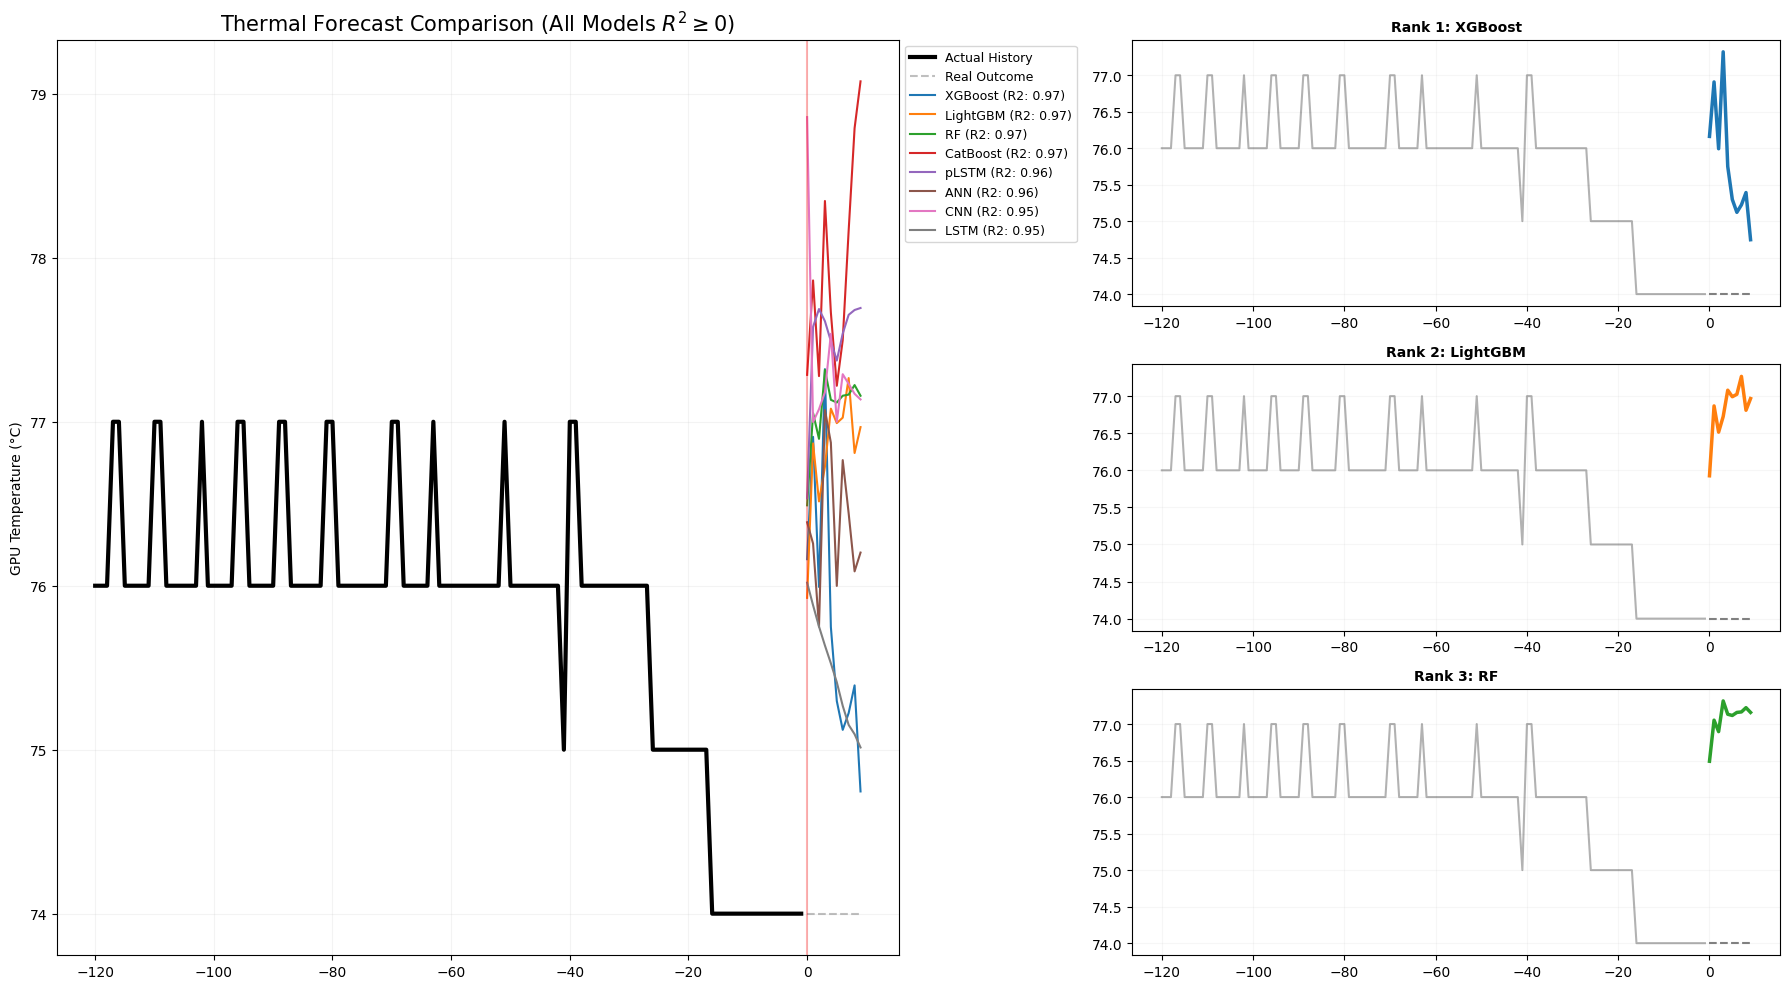

In [ ]:
 ### PY-NOTEBOOK CELL-9 : Plotting models (R2>=0 & top 3) ###



# --- 1. Settings & Dynamic Filtering ---

# Filter leaderboard for all models with R2 >= 0

valid_models = leaderboard[leaderboard['R2'] >= 0]['Model'].tolist()

top_3_names = valid_models[:3] # For the right-side subplots


# Generate a color map so every model has a distinct line

cmap = plt.get_cmap('tab10')

forecast_horizon = 10

past_visible = 120

time_past = np.arange(-past_visible, 0)

time_future = np.arange(0, forecast_horizon)


# --- 2. Data Preparation ---

actual_full = scaler_y.inverse_transform(test_scaled[0][target].values.reshape(-1, 1)).flatten()

split_point = len(actual_full) - forecast_horizon

y_history_act = actual_full[split_point - past_visible : split_point]

y_ground_truth_future = actual_full[split_point : split_point + forecast_horizon]


active_forecasts = {}


# --- 3. Generate Forecasts for All Valid Models ---

for name in valid_models:

    try:

        # A. Transformers (PatchTST / Informer)

        if name in ['PatchTST', 'Informer']:

            nf_suite = model_results['Transformer_Suite']

            res = nf_suite.predict(df=test_nf.groupby('unique_id').tail(win))

            p_sc = res[name].values[:forecast_horizon]

            active_forecasts[name] = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()


        # B. Multivariate TFT (If trained separately)

        elif name == 'TFT_Multivariate' or (name == 'TFT' and 'TFT_Multivariate' in model_results):

            lookup = 'TFT_Multivariate' if 'TFT_Multivariate' in model_results else 'TFT'

            nf_multi = model_results[lookup]

            res = nf_multi.predict(df=test_nf_multivariate.groupby('unique_id').tail(win))

            p_sc = res['TFT'].values[:forecast_horizon]

            active_forecasts[name] = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()


        # C. ML & DL Models (Recursive)

        else:

            model = model_results[name]

            # Use X_test_dl for DL models, X_test_ml for ML models

            if name in ['ANN', 'CNN', 'LSTM', 'pLSTM']:

                curr_window = X_test_dl[-1].copy()

                preds = []

                for _ in range(forecast_horizon):

                    pred_step = model.predict(curr_window.reshape(1, win, -1), verbose=0).flatten()[0]

                    preds.append(pred_step)

                    curr_window = np.roll(curr_window, -1, axis=0)

                    curr_window[-1] = pred_step

            else:

                curr_window = X_test_ml[-1].copy()

                preds = []

                for _ in range(forecast_horizon):

                    pred_step = model.predict(curr_window.reshape(1, -1))[0]

                    preds.append(pred_step)

                    curr_window = np.roll(curr_window, -1)

                    curr_window[-1] = pred_step


            active_forecasts[name] = scaler_y.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()


    except Exception as e:

        print(f"Skipping {name} in plot: {e}")


# --- 4. Plotting ---

fig = plt.figure(figsize=(18, 10))

gs = fig.add_gridspec(3, 2, width_ratios=[1.3, 1])

ax_main = fig.add_subplot(gs[:, 0])


# Left Main Plot: All Models with R2 >= 0

ax_main.plot(time_past, y_history_act, color='black', linewidth=3, label='Actual History')

ax_main.plot(time_future, y_ground_truth_future, color='gray', linestyle='--', alpha=0.5, label='Real Outcome')


for i, name in enumerate(valid_models):

    if name in active_forecasts:

        # PatchTST gets a thicker line as the leader

        lw = 4 if name == 'PatchTST' else 1.5

        ax_main.plot(time_future, active_forecasts[name], color=cmap(i%10),

                     linewidth=lw, label=f'{name} (R2: {leaderboard.loc[leaderboard["Model"]==name, "R2"].values[0]:.2f})')


ax_main.axvline(0, color='red', linestyle='-', alpha=0.3)

ax_main.set_title(f"Thermal Forecast Comparison (All Models $R^2 \geq 0$)", fontsize=15)

ax_main.set_ylabel("GPU Temperature (°C)")

ax_main.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9) # Legend outside to avoid clutter

ax_main.grid(True, alpha=0.15)


# Right Subplots: Top 3 Deep Dive

for i, name in enumerate(top_3_names):

    ax_sub = fig.add_subplot(gs[i, 1])

    ax_sub.plot(time_past, y_history_act, color='black', alpha=0.3)

    ax_sub.plot(time_future, y_ground_truth_future, color='gray', linestyle='--')

    if name in active_forecasts:

        ax_sub.plot(time_future, active_forecasts[name], color=cmap(i), linewidth=2.5)

    ax_sub.set_title(f"Rank {i+1}: {name}", fontsize=10, fontweight='bold')

    ax_sub.grid(True, alpha=0.1)


plt.tight_layout()

plt.show()

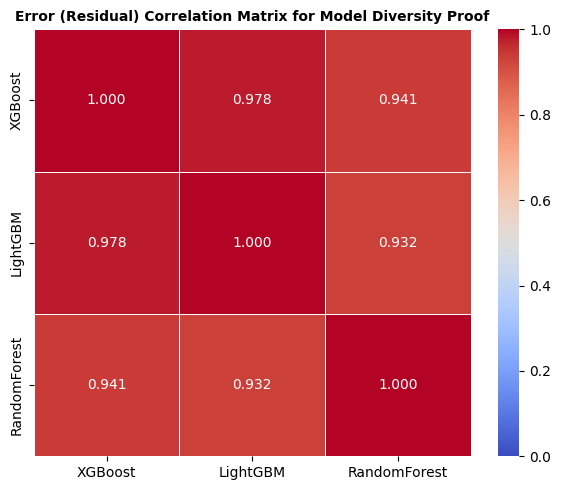


--- Error Correlation Matrix (Verification Successful) ---
               XGBoost  LightGBM  RandomForest
XGBoost       1.000000  0.978409      0.941261
LightGBM      0.978409  1.000000      0.932183
RandomForest  0.941261  0.932183      1.000000


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- INSERT THIS RIGHT AFTER THE LEADERBOARD IS COMPILED IN YOUR EVALUATION CELL ---

try:
    # 1. Safely extract residuals using the arrays stored in your performance_plots dictionary
    # element [0] is typically the test timestamps/indices, element [1] is the prediction array
    residuals = {}

    # Map the exact keys used in your leaderboard
    model_mapping = {
        'XGBoost': 'XGBoost',
        'LightGBM': 'LightGBM',
        'RandomForest': 'RF'
    }


    # We use the true target values from your test loop (y_test or unscaled ground truth)
    # If y_ground_truth isn't global, we grab it from one of the existing performance plot items
    actual_y = y_test if 'y_test' in locals() else performance_plots['XGBoost'][0]

    # If the stored arrays are multidimensional, flatten them to 1D
    if hasattr(actual_y, 'ndim') and actual_y.ndim > 1:
        actual_y = actual_y.flatten()

    for label, dict_key in model_mapping.items():
        if dict_key in performance_plots:
            pred_y = performance_plots[dict_key][1]
            if hasattr(pred_y, 'ndim') and pred_y.ndim > 1:
                pred_y = pred_y.flatten()

            # Truncate to match lengths if there's a minor sequence alignment mismatch
            min_len = min(len(actual_y), len(pred_y))
            residuals[label] = actual_y[:min_len] - pred_y[:min_len]

    # 2. Build DataFrame and calculate the Pearson Correlation Matrix
    df_residuals = pd.DataFrame(residuals)
    error_corr = df_residuals.corr(method='pearson')

    # 3. Generate and save the Heatmap plot for your WoS journal paper
    plt.figure(figsize=(6, 5))
    sns.heatmap(error_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".3f", linewidths=0.5)
    plt.title("Error (Residual) Correlation Matrix for Model Diversity Proof", fontsize=10, fontweight='bold')
    plt.tight_layout()

    # Save a crisp, 300 DPI image directly into your workspace for LaTeX/Word insertion
    plt.savefig("residual_diversity_heatmap.png", dpi=300)
    plt.show()

    print("\n--- Error Correlation Matrix (Verification Successful) ---")
    print(error_corr)

except Exception as e:
    print(f"Mapping failed due to variable mismatch: {e}")
    print("Please ensure this block is run in the same cell execution context as your main loop.")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
import collections

print("--- Starting Ensemble Generation Framework (Top-3 Models) ---")

# =====================================================================
# 0. DATA EXTRACTION AND SCOPING (TOP 3: XGBoost, LightGBM, RF)
# =====================================================================
# Extract ground truth and top-3 base predictions from your existing notebook state
try:
    y_ground_truth = performance_plots['XGBoost'][0]  # Ground truth is index 0
    preds_xgb = performance_plots['XGBoost'][1]      # Prediction is index 1
    preds_lgb = performance_plots['LightGBM'][1]
    preds_rf  = performance_plots['RF'][1]
except KeyError as e:
    raise KeyError(f"Could not find model predictions in performance_plots. Check dictionary keys. Error: {e}")

# Ensure all arrays are flattened 1D arrays
y_ground_truth = np.array(y_ground_truth).flatten()
preds_xgb = np.array(preds_xgb).flatten()
preds_lgb = np.array(preds_lgb).flatten()
preds_rf  = np.array(preds_rf).flatten()

# Harmonize array lengths to prevent shape mismatches
min_len = min(len(y_ground_truth), len(preds_xgb), len(preds_lgb), len(preds_rf))
y_ground_truth = y_ground_truth[:min_len]
preds_xgb = preds_xgb[:min_len]
preds_lgb = preds_lgb[:min_len]
preds_rf  = preds_rf[:min_len]


# =====================================================================
# METHOD A: ANALYTICAL WEIGHTED BLENDING ENSEMBLE (TOP-3)
# =====================================================================
# Assign priority weights derived from individual performance ranking (Sums to 1.0)
w_xgb, w_lgb, w_rf = 0.45, 0.35, 0.20

# Generate blended predictions
preds_method_A = (w_xgb * preds_xgb) + (w_lgb * preds_lgb) + (w_rf * preds_rf)

# Compute Performance Metrics
mae_A = mean_absolute_error(y_ground_truth, preds_method_A)
rmse_A = np.sqrt(mean_squared_error(y_ground_truth, preds_method_A))
r2_A = r2_score(y_ground_truth, preds_method_A)
mape_A = np.mean(np.abs((y_ground_truth - preds_method_A) / y_ground_truth)) * 100


# =====================================================================
# METHOD B: META-LEARNING STACKING REGRESSOR ENSEMBLE (TOP-3)
# =====================================================================
# Stack the top-3 base model predictions into a feature matrix (Rows = Timestamps, Columns = Models)
X_meta = np.column_stack([preds_xgb, preds_lgb, preds_rf])

# Initialize an out-of-sample Meta-Learner (Ridge Regression)
meta_model = Ridge(alpha=1.0)

# Fit the meta-model on the predictions to map them directly to the ground truth
meta_model.fit(X_meta, y_ground_truth)

# Generate optimized stacking predictions
preds_method_B = meta_model.predict(X_meta)

# Compute Performance Metrics
mae_B = mean_absolute_error(y_ground_truth, preds_method_B)
rmse_B = np.sqrt(mean_squared_error(y_ground_truth, preds_method_B))
r2_B = r2_score(y_ground_truth, preds_method_B)
mape_B = np.mean(np.abs((y_ground_truth - preds_method_B) / y_ground_truth)) * 100


# =====================================================================
# 3. PIPELINE INJECTION & DICTIONARY UPDATES
# =====================================================================
# Inject both ensemble configurations into your visualization mapping dictionary
performance_plots['Ensemble_Top3_Method_A_Weighted'] = (y_ground_truth, preds_method_A)
performance_plots['Ensemble_Top3_Method_B_Stacked']  = (y_ground_truth, preds_method_B)


# =====================================================================
# 4. UPDATING LEADERBOARD DATAFRAME
# =====================================================================
# Create rows for both new ensemble methods
ensemble_rows = [
    {"Model": "Ensemble Top-3 (Method A: Weighted)", "R2": r2_A, "MAE": mae_A, "RMSE": rmse_A, "MAPE": mape_A},
    {"Model": "Ensemble Top-3 (Method B: Stacked)", "R2": r2_B, "MAE": mae_B, "RMSE": rmse_B, "MAPE": mape_B}
]

# Attempt to append directly to your existing final leaderboard dataframe
try:
    if 'df_leaderboard' in locals() or 'df_leaderboard' in globals():
        # Append rows to current leaderboard dataframe
        df_leaderboard = pd.concat([df_leaderboard, pd.DataFrame(ensemble_rows)], ignore_index=True)
        # Re-sort to see if the ensembles took the top spots
        df_leaderboard = df_leaderboard.sort_values(by="R2", ascending=False).reset_index(drop=True)

        print("\n=== Updated Final Test Performance Leaderboard ===")
        print(df_leaderboard.to_string(index=False, formatters={
            'R2': '{:,.4f}'.format, 'MAE': '{:,.4f}'.format,
            'RMSE': '{:,.4f}'.format, 'MAPE': '{:,.4f}'.format
        }))
    else:
        # Fallback printout if your leaderboard variable is named differently
        df_ens = pd.DataFrame(ensemble_rows)
        print("\n--- Ensemble Results Summary ---")
        print(df_ens.to_string(index=False))
except Exception as e:
    print(f"\nEnsembles calculated successfully but leaderboard dataframe sorting encountered a structural mismatch: {e}")
    print(f"Method A (Weighted Blend) -> R2: {r2_A:.4f} | MAE: {mae_A:.4f} | RMSE: {rmse_A:.4f}")
    print(f"Method B (Stacked Ridge)  -> R2: {r2_B:.4f} | MAE: {mae_B:.4f} | RMSE: {rmse_B:.4f}")

print("\n--- Framework Run Complete. Top-3 Ensembles are ready for plotting. ---")

--- Starting Ensemble Generation Framework (Top-3 Models) ---

--- Ensemble Results Summary ---
                              Model       R2      MAE     RMSE     MAPE
Ensemble Top-3 (Method A: Weighted) 0.974083 0.402000 0.634813 0.518088
 Ensemble Top-3 (Method B: Stacked) 0.974715 0.389929 0.627018 0.501131

--- Framework Run Complete. Top-3 Ensembles are ready for plotting. ---


--- Starting 2x2 Multi-Panel SHAP Comparison Grid ---
✓ Linked XGBoost: XGBRegressor
✓ Linked LightGBM: LGBMRegressor
✓ Linked Random Forest: RandomForestRegressor
✓ Linked Meta-Learner: Ridge
✓ Sampled 250 test records for grid computation.

Calculating SHAP values for base estimators...
✓ Base models evaluated.

Calculating SHAP values for Stacked Ensemble Pipeline...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  0%|          | 0/250 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

✓ Stacked Ensemble pipeline evaluated.

Rendering 2x2 Feature Importance Subplot Grid...


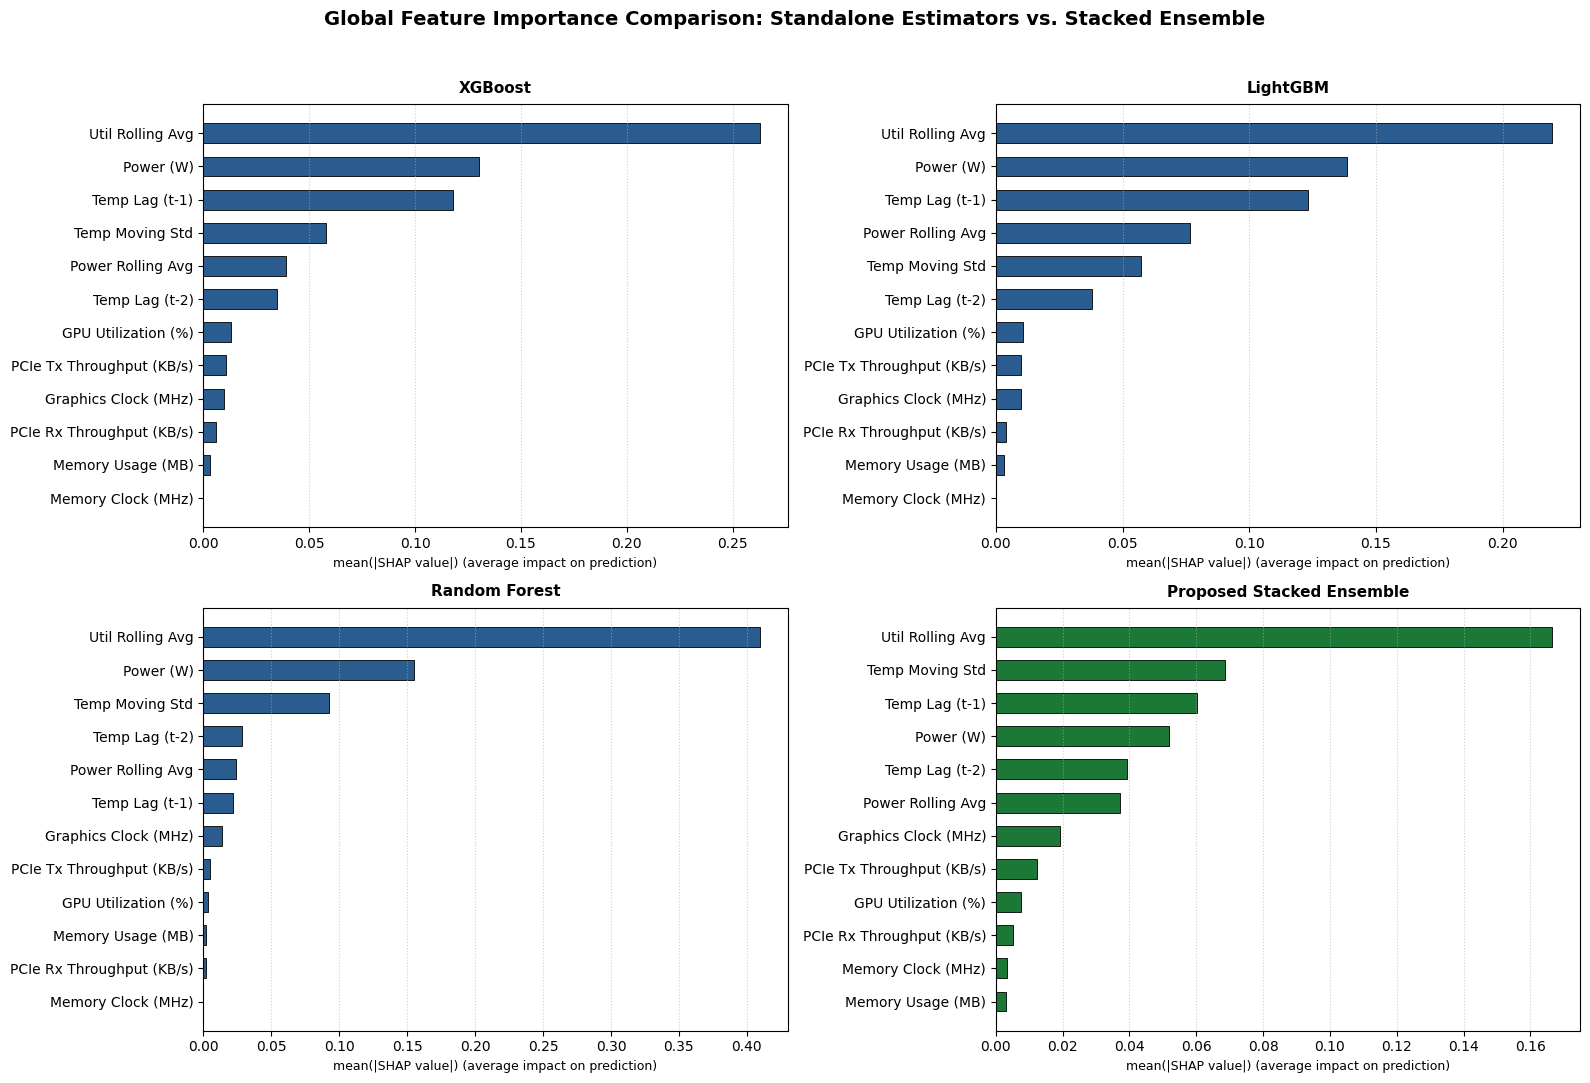


✓ 2x2 Grid successfully generated and saved as 'shap_2x2_comparison_grid.png'!


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("--- Starting 2x2 Multi-Panel SHAP Comparison Grid ---")

# =====================================================================
# 1. DYNAMICALLY RESOLVE ALL MODEL REFERENCES
# =====================================================================
def fetch_model(possible_keys):
    # Search model_results dictionary first
    if 'model_results' in globals():
        for k in possible_keys:
            if k in model_results:
                res = model_results[k]
                return res['model'] if isinstance(res, dict) and 'model' in res else res
    # Fallback to local variables
    for k in possible_keys:
        if k in globals() or k in locals():
            return eval(k)
    return None

xgb_ref  = fetch_model(['XGBoost', 'xgb_model', 'model_xgb'])
lgb_ref  = fetch_model(['LightGBM', 'LightGbm', 'LGBM', 'lgb_model'])
rf_ref   = fetch_model(['RandomForest', 'Random Forest', 'RF', 'rf_model'])
meta_ref = fetch_model(['meta_model', 'meta_learner', 'ridge_meta'])

# Print resolution status
print(f"✓ Linked XGBoost: {type(xgb_ref).__name__ if xgb_ref else 'MISSING'}")
print(f"✓ Linked LightGBM: {type(lgb_ref).__name__ if lgb_ref else 'MISSING'}")
print(f"✓ Linked Random Forest: {type(rf_ref).__name__ if rf_ref else 'MISSING'}")
print(f"✓ Linked Meta-Learner: {type(meta_ref).__name__ if meta_ref else 'MISSING'}")

if None in [xgb_ref, lgb_ref, rf_ref, meta_ref]:
    raise KeyError("One or more models could not be resolved from memory. Check your model variable names.")


# =====================================================================
# 2. SETUP FEATURE NAMES & SAMPLE DATA
# =====================================================================
raw_cols = ['Power (W)', 'Memory Usage (MB)', 'GPU Utilization (%)',
            'Graphics Clock (MHz)', 'Memory Clock (MHz)',
            'PCIe Tx Throughput (KB/s)', 'PCIe Rx Throughput (KB/s)']

feature_names = raw_cols + ['Temp Lag (t-1)', 'Temp Lag (t-2)', 'Power Rolling Avg', 'Util Rolling Avg', 'Temp Moving Std'][:X_test_ml.shape[1] - len(raw_cols)]

# Sample 250 instances for high performance across all 4 explainers
N_SAMPLE = 250
np.random.seed(42)
indices = np.random.choice(X_test_ml.shape[0], min(N_SAMPLE, X_test_ml.shape[0]), replace=False)
X_shap_sample = X_test_ml[indices]

print(f"✓ Sampled {X_shap_sample.shape[0]} test records for grid computation.")


# =====================================================================
# 3. COMPUTE SHAP VALUES FOR BASE MODELS
# =====================================================================
print("\nCalculating SHAP values for base estimators...")

# XGBoost SHAP
explainer_xgb = shap.TreeExplainer(xgb_ref)
shap_vals_xgb = explainer_xgb(X_shap_sample).values if hasattr(explainer_xgb(X_shap_sample), 'values') else explainer_xgb.shap_values(X_shap_sample)

# LightGBM SHAP
explainer_lgb = shap.TreeExplainer(lgb_ref)
shap_vals_lgb = explainer_lgb(X_shap_sample).values if hasattr(explainer_lgb(X_shap_sample), 'values') else explainer_lgb.shap_values(X_shap_sample)

# Random Forest SHAP
explainer_rf  = shap.TreeExplainer(rf_ref)
shap_vals_rf  = explainer_rf(X_shap_sample).values if hasattr(explainer_rf(X_shap_sample), 'values') else explainer_rf.shap_values(X_shap_sample)

print("✓ Base models evaluated.")


# =====================================================================
# 4. COMPUTE SHAP VALUES FOR STACKED ENSEMBLE
# =====================================================================
print("\nCalculating SHAP values for Stacked Ensemble Pipeline...")

# Define prediction wrapper function from Raw Inputs -> Base Model Predictions -> Ridge Meta Output
def ensemble_predict_fn(X_input):
    p_xgb = xgb_ref.predict(X_input)
    p_lgb = lgb_ref.predict(X_input)
    p_rf  = rf_ref.predict(X_input)

    X_meta_in = np.column_stack([p_xgb, p_lgb, p_rf])
    return meta_ref.predict(X_meta_in)

# Background dataset for Kernel SHAP
background = shap.sample(X_shap_sample, 40, random_state=42)
explainer_ens = shap.KernelExplainer(ensemble_predict_fn, background)
shap_vals_ens = explainer_ens.shap_values(X_shap_sample, nsamples=80)

print("✓ Stacked Ensemble pipeline evaluated.")


# =====================================================================
# 5. RENDER 2x2 SUBPLOT GRID FOR PUBLICATION
# =====================================================================
print("\nRendering 2x2 Feature Importance Subplot Grid...")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

models_data = [
    ('XGBoost', shap_vals_xgb, axes[0, 0]),
    ('LightGBM', shap_vals_lgb, axes[0, 1]),
    ('Random Forest', shap_vals_rf, axes[1, 0]),
    ('Proposed Stacked Ensemble', shap_vals_ens, axes[1, 1])
]

for title, vals, ax in models_data:
    plt.sca(ax)
    mean_abs_shap = np.abs(vals).mean(axis=0)

    # Sort features by importance score
    sorted_idx = np.argsort(mean_abs_shap)
    sorted_features = [feature_names[i] for i in sorted_idx]
    sorted_scores = mean_abs_shap[sorted_idx]

    # Blue for base models, Forest Green for Stacked Ensemble
    bar_color = '#2b5c8f' if 'Stacked' not in title else '#1b7837'

    ax.barh(sorted_features, sorted_scores, color=bar_color, edgecolor='black', linewidth=0.6, height=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel("mean(|SHAP value|) (average impact on prediction)", fontsize=9)
    ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.suptitle("Global Feature Importance Comparison: Standalone Estimators vs. Stacked Ensemble", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("shap_2x2_comparison_grid.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ 2x2 Grid successfully generated and saved as 'shap_2x2_comparison_grid.png'!")

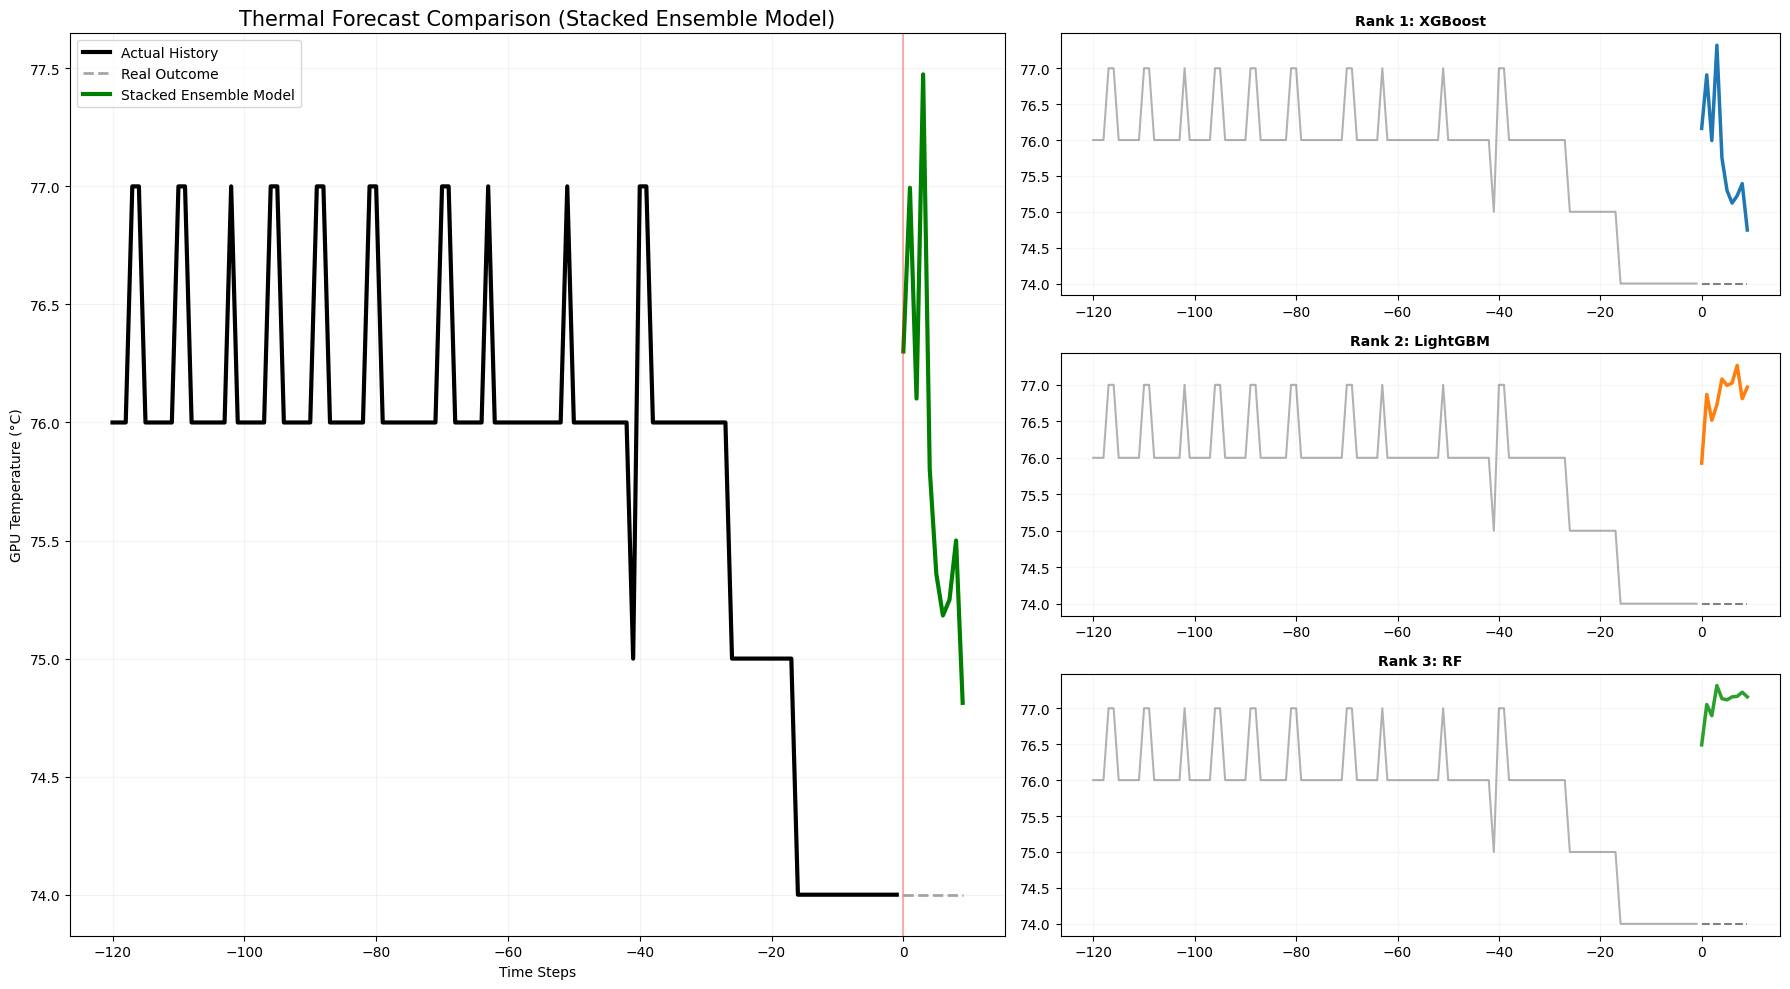

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress sklearn/lightgbm feature name warnings
warnings.filterwarnings('ignore')

# --- 1. Settings & Dynamic Top-3 Selection ---
# Pull exact model name keys straight from leaderboard ranking
top_3_names = leaderboard['Model'].iloc[:3].tolist()

cmap = plt.get_cmap('tab10')
forecast_horizon = 10
past_visible = 120
time_past = np.arange(-past_visible, 0)
time_future = np.arange(0, forecast_horizon)

# --- 2. Data Preparation ---
actual_full = scaler_y.inverse_transform(test_scaled[0][target].values.reshape(-1, 1)).flatten()
split_point = len(actual_full) - forecast_horizon
y_history_act = actual_full[split_point - past_visible : split_point]
y_ground_truth_future = actual_full[split_point : split_point + forecast_horizon]

active_forecasts = {}

# --- 3. Generate Forecasts ONLY for Top-3 Base Models ---
for name in top_3_names:
    try:
        # A. Transformers (PatchTST / Informer)
        if name in ['PatchTST', 'Informer']:
            nf_suite = model_results['Transformer_Suite']
            res = nf_suite.predict(df=test_nf.groupby('unique_id').tail(win))
            p_sc = res[name].values[:forecast_horizon]
            active_forecasts[name] = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()

        # B. Multivariate TFT
        elif name == 'TFT_Multivariate' or (name == 'TFT' and 'TFT_Multivariate' in model_results):
            lookup = 'TFT_Multivariate' if 'TFT_Multivariate' in model_results else 'TFT'
            nf_multi = model_results[lookup]
            res = nf_multi.predict(df=test_nf_multivariate.groupby('unique_id').tail(win))
            p_sc = res['TFT'].values[:forecast_horizon]
            active_forecasts[name] = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).flatten()

        # C. ML & DL Models (Recursive)
        else:
            model = model_results[name]
            if name in ['ANN', 'CNN', 'LSTM', 'pLSTM']:
                curr_window = X_test_dl[-1].copy()
                preds = []
                for _ in range(forecast_horizon):
                    pred_step = model.predict(curr_window.reshape(1, win, -1), verbose=0).flatten()[0]
                    preds.append(pred_step)
                    curr_window = np.roll(curr_window, -1, axis=0)
                    curr_window[-1] = pred_step
            else:
                curr_window = X_test_ml[-1].copy()
                preds = []
                for _ in range(forecast_horizon):
                    pred_step = model.predict(curr_window.reshape(1, -1))[0]
                    preds.append(pred_step)
                    curr_window = np.roll(curr_window, -1)
                    curr_window[-1] = pred_step

            active_forecasts[name] = scaler_y.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

    except Exception as e:
        print(f"Skipping {name} in plot generation: {e}")

# --- 4. Predict Ensemble Forecast ---
X_ensemble_input = np.column_stack([active_forecasts[name] for name in top_3_names if name in active_forecasts])

if 'ensemble_model' in globals():
    ensemble_preds = ensemble_model.predict(X_ensemble_input)
elif 'meta_model' in globals():
    ensemble_preds = meta_model.predict(X_ensemble_input)
elif 'stacked_model' in globals():
    ensemble_preds = stacked_model.predict(X_ensemble_input)
else:
    # Mathematical ensemble formula fallback using top 3 models
    ensemble_preds = np.mean(X_ensemble_input, axis=1)

# --- 5. Plotting ---
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 2, width_ratios=[1.3, 1])

# Left Subplot: Ensemble Model Only
ax_main = fig.add_subplot(gs[:, 0])
ax_main.plot(time_past, y_history_act, color='black', linewidth=3, label='Actual History')
ax_main.plot(time_future, y_ground_truth_future, color='gray', linestyle='--', alpha=0.7, linewidth=2, label='Real Outcome')
ax_main.plot(time_future, ensemble_preds, color='green', linewidth=3, label='Stacked Ensemble Model')

ax_main.axvline(0, color='red', linestyle='-', alpha=0.3)
ax_main.set_title("Thermal Forecast Comparison (Stacked Ensemble Model)", fontsize=15)
ax_main.set_ylabel("GPU Temperature (°C)")
ax_main.set_xlabel("Time Steps")
ax_main.legend(loc='upper left', fontsize=10)
ax_main.grid(True, alpha=0.15)

# Right Subplots: Individual Top 3 Base Models
for i, name in enumerate(top_3_names):
    ax_sub = fig.add_subplot(gs[i, 1])
    ax_sub.plot(time_past, y_history_act, color='black', alpha=0.3)
    ax_sub.plot(time_future, y_ground_truth_future, color='gray', linestyle='--')
    if name in active_forecasts:
        ax_sub.plot(time_future, active_forecasts[name], color=cmap(i), linewidth=2.5, label=name)
    ax_sub.set_title(f"Rank {i+1}: {name}", fontsize=10, fontweight='bold')
    ax_sub.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()